<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Monte_Carlo_Sim_Fib_Fractal_Res_S21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q cupy-cuda12x matplotlib scipy gdstk

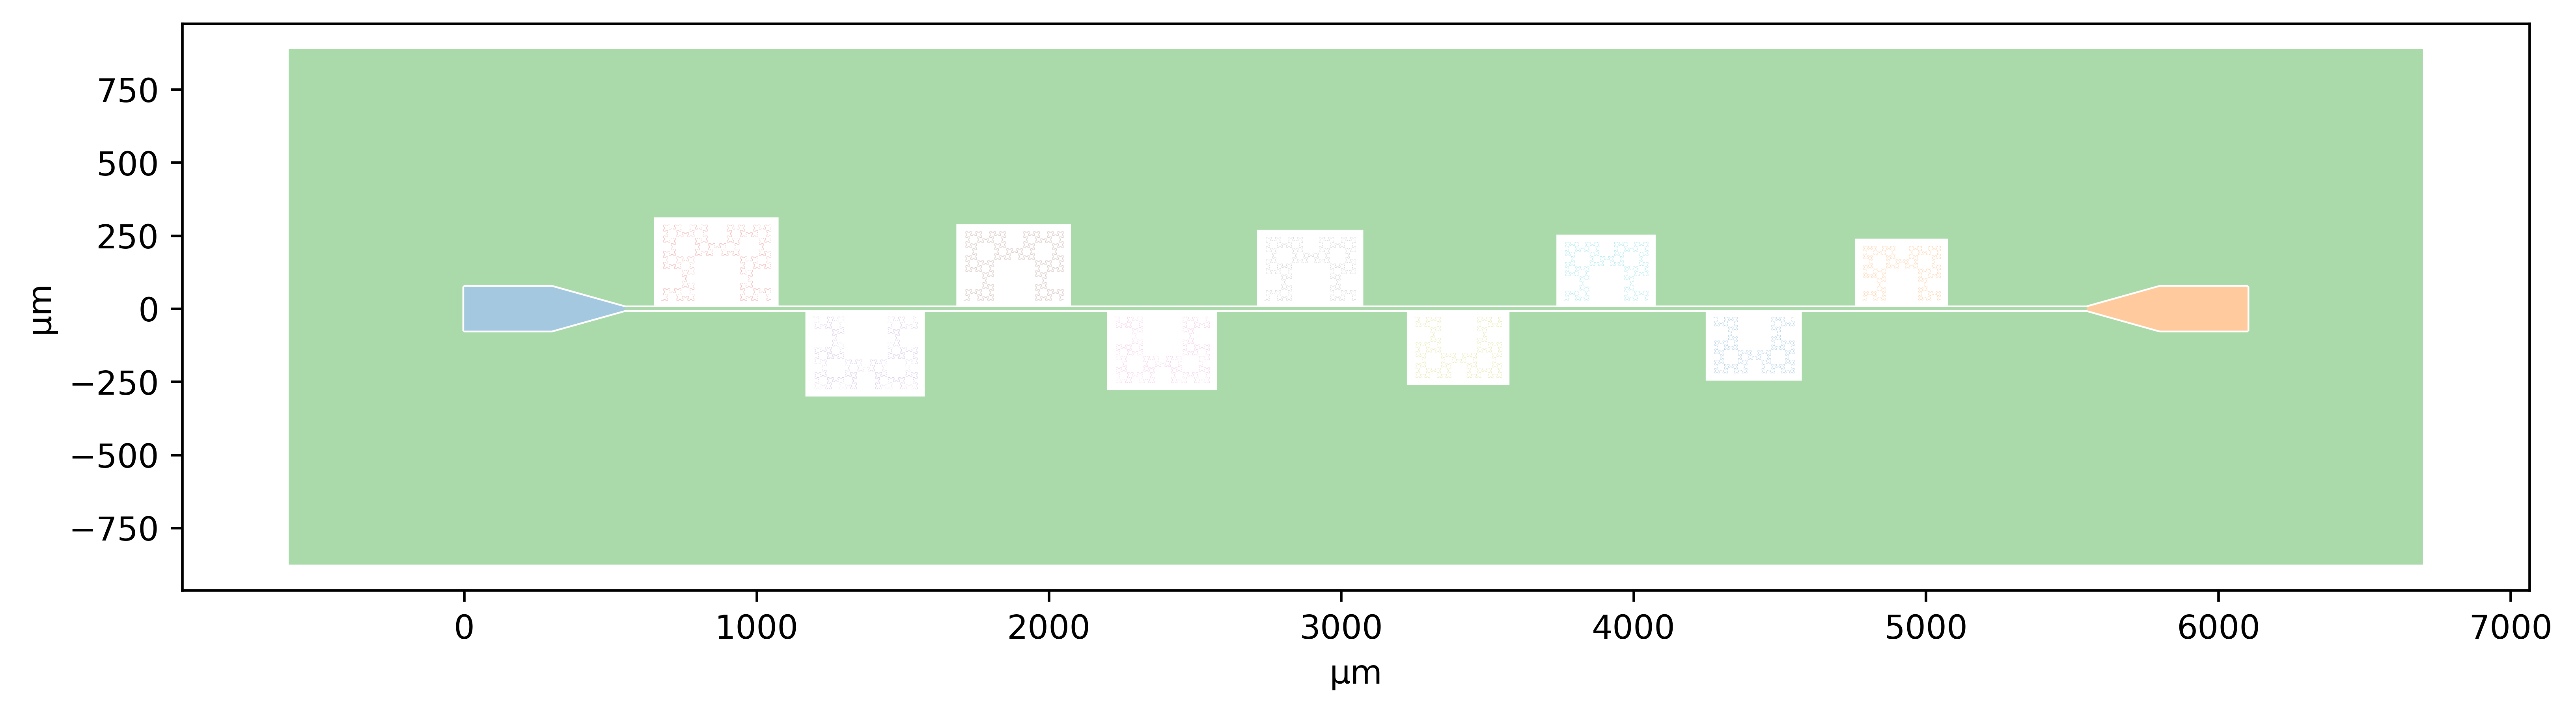


OASIS written to cpw_fibonacci_resonators_v12_square_cavities_control_knobs.oas



In [2]:
#!/usr/bin/env python3
"""
CPW Feed with Rotated Fibonacci–Fractal λ/4 Metamaterial Resonators
(no IDCs) — Resonators placed with adjustable spacing and count

Author   : Onri Jay Benally / Modified with control knobs
Date     : 2025-06-06
───────────────────────────────────────────
Run locally or in Colab:

    pip install gdstk matplotlib
    python cpw_fibonacci_resonators_v12_control_knobs.py

Outputs:
    • Interactive preview window (Matplotlib)
    • cpw_fibonacci_resonators_v12_square_cavities_control_knobs.oas   (OASIS-v1.0 layout)
"""
# ───────────────────────────────────
# 0) Imports & Matplotlib style
# ───────────────────────────────────
import gdstk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

mpl.rcParams["figure.dpi"] = 600

# ───────────────────────────────────
# Control Knobs: Adjust these values to change fractal behavior
# ───────────────────────────────────
# Number of Fibonacci-word iterations (higher → more complex fractal)
FIB_ITER = 15                # integer: 1, 2, 3, …
# Fraction of step length used as bend radius in FlexPath (0 → sharp corners, up to 0.5 or more)
FRACTAL_FILLET_FACTOR = 0.4  # float: 0.0 to 1.0 (or higher for smoother arcs)
# Vertical spacing (gap) between CPW feed and resonator (controls stagger spacing)
FRACTAL_SPACING = 20.0       # µm   baseline gap from feed conductor to fractal anchor
# Horizontal spacing between adjacent fractals (center-to-center)
FRACTAL_HORZ_SPACING = 500.0 # µm   horizontal pitch between resonators
# Number of resonators to place
NUM_RESONATORS = 9           # integer: how many staggered fractals
# Frequency range for resonators (GHz)
FREQ_MIN = 5.0               # GHz   lowest resonance
FREQ_MAX = 7.0               # GHz   highest resonance

# ───────────────────────────────────
# 1) Technology & Electrical Design Parameters
# ───────────────────────────────────
tech = dict(
    # — CPW feed line (feed_len computed based on FRACTAL_HORZ_SPACING and NUM_RESONATORS) —
    w_feed=10.0,               # µm   centre-conductor width
    g_feed=6.0,                # µm   gap to ground
    feed_len=None,             # µm   placeholder; auto-calculated later

    # — Fibonacci-fractal resonators —
    w_res=1.0,                 # µm   resonator trace width
    g_res=6.0,                 # µm   keep-out gap (unused)
    fib_iter=FIB_ITER,         # iterations of Fibonacci word
    fractal_fillet_factor=FRACTAL_FILLET_FACTOR,  # bend radius factor
    fractal_spacing=FRACTAL_SPACING,  # µm   vertical spacing from CPW feed
    fractal_horz_spacing=FRACTAL_HORZ_SPACING,  # µm   horizontal spacing
    d_feed_res=2.0,            # µm   (unused)

    # — Launch pads (rectangular pad + linear taper) —
    pad_len=300.0,             # µm   pad length
    pad_wid=150.0,             # µm   pad width
    pad_taper_len=250.0,       # µm   taper length (w_feed → pad_wid)

    # — Square cavity margin —
    sq_margin=50.0,            # µm   margin around each fractal for square cavity
    fillet_radius=25.0,        # µm   radius for filleted cavity corners

    # — Cavity & chip frame —
    cavity_margin=12.0,        # µm   clearance around each resonator for precise cavity
    margin=600.0,              # µm   ground-to-edge clearance
)
tech["g_max"] = max(tech["g_feed"], tech["g_res"])

# λ/4 electrical lengths based on chosen frequency range and number of resonators
LQ_5GHZ = 6000.0  # µm quarter-wave at 5 GHz in this substrate
freqs = np.linspace(FREQ_MIN, FREQ_MAX, NUM_RESONATORS)  # GHz array of resonant frequencies
lambda_quarters = LQ_5GHZ * FREQ_MIN / freqs  # µm per resonator for λ/4 scaling

# ───────────────────────────────────
# 2) Build the Fibonacci-word unit polyline (no truncation)
# ───────────────────────────────────
_DIRECTIONS = (
    np.array([1, 0]),   # →
    np.array([0, 1]),   # ↑
    np.array([-1, 0]),  # ←
    np.array([0, -1]),  # ↓
)

def fibonacci_word(n: int) -> str:
    """Return the n-th Fibonacci word (F₁='0', F₂='01', …)."""
    a, b = "0", "01"
    for _ in range(n - 1):
        a, b = b, b + a
    return b

# Compute the unit-step polyline for the chosen iteration
_FIB_WORD = fibonacci_word(tech["fib_iter"])
_unit_polyline = [np.array([0.0, 0.0])]
cur_dir = 0
for idx, ch in enumerate(_FIB_WORD):
    if ch == "1":
        _unit_polyline.append(_unit_polyline[-1] + _DIRECTIONS[cur_dir])
    else:  # ch == '0' ⇒ turn then step
        cur_dir = (cur_dir + (1 if idx % 2 == 0 else -1)) % 4
        _unit_polyline.append(_unit_polyline[-1] + _DIRECTIONS[cur_dir])
_unit_polyline = np.asarray(_unit_polyline)
_NUM_MOVES = len(_unit_polyline) - 1
_UNIT_WIDTH = _unit_polyline[:, 0].max() - _unit_polyline[:, 0].min()
_BOUND_RATIO = _UNIT_WIDTH / _NUM_MOVES  # dimensionless

# ───────────────────────────────────
# 3) Helper: quick preview
# ───────────────────────────────────

def preview(cell, figsize=(9, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    try:
        cell.plot(ax)
    except AttributeError:
        for poly in cell.polygons:
            ax.fill(*zip(*poly.points), alpha=0.4, lw=0.25)
    ax.set_aspect("equal")
    ax.set_xlabel("µm")
    ax.set_ylabel("µm")
    plt.tight_layout()
    plt.show()

# ───────────────────────────────────
# 4) Geometry utilities
# ───────────────────────────────────

def rect(x0, y0, x1, y1):
    return gdstk.rectangle((x0, y0), (x1, y1))


def build_straight_cpw(origin, length, width):
    x0, y0 = origin
    return [rect(x0, y0 - width/2, x0 + length, y0 + width/2)]


def build_launch_pad(origin_x: float, y0: float, direction: int, p: dict) -> gdstk.Polygon:
    """Linear taper from feed width to pad width followed by rectangular pad."""
    w1, w2 = p["w_feed"], p["pad_wid"]
    t_len, pad_len = p["pad_taper_len"], p["pad_len"]
    x_feed = origin_x
    x_taper_end = x_feed + direction * t_len
    x_pad_end = x_taper_end + direction * pad_len
    pts = [
        (x_feed,      y0 + w1/2),
        (x_taper_end, y0 + w2/2),
        (x_pad_end,   y0 + w2/2),
        (x_pad_end,   y0 - w2/2),
        (x_taper_end, y0 - w2/2),
        (x_feed,      y0 - w1/2),
    ]
    return gdstk.Polygon(pts)

# ───────────────────────────────────
# 5) Build one Fibonacci-fractal resonator (rotated left 90°)
# ───────────────────────────────────

def rotate_left_90(pts: np.ndarray) -> np.ndarray:
    """Rotate points left (CCW) by 90° about origin."""
    return np.column_stack((-pts[:, 1], pts[:, 0]))


def build_fibonacci_resonator(origin, lambda_q, p, upward=True):
    """
    Return a list of polygons for one Fibonacci resonator (rotated left 90°).
    """
    step = lambda_q / _NUM_MOVES
    pts = _unit_polyline * step
    pts = rotate_left_90(pts)
    if not upward:
        pts = pts.copy()
        pts[:, 1] *= -1
    pts += np.asarray(origin) - pts[0]
    # use control knob for bend radius
    bend_radius = step * p.get("fractal_fillet_factor", 0.5)
    fp = gdstk.FlexPath(
        pts.tolist(), p["w_res"], bend_radius=bend_radius, simple_path=True
    )
    return fp.to_polygons()

# ───────────────────────────────────
# 6) Assemble the full chip with large filleted square cavities
# ───────────────────────────────────

def build_full_chip(p):
    lib = gdstk.Library(unit=1e-6)
    cell = lib.new_cell("MAIN")
    conductors = []
    cavities = []

    # Compute feed_len based on horizontal spacing and number of resonators
    num_res = NUM_RESONATORS
    inset = p.get("fractal_horz_spacing", 0.0)
    total_res_width = (num_res - 1) * p.get("fractal_horz_spacing", 0.0)
    p["feed_len"] = 2 * inset + total_res_width

    # Pads + feed line using updated feed_len
    feed_x0 = p["pad_len"] + p["pad_taper_len"]
    pad_left = build_launch_pad(feed_x0, 0.0, -1, p)
    pad_right = build_launch_pad(feed_x0 + p["feed_len"], 0.0, +1, p)
    feed_line = build_straight_cpw((feed_x0, 0.0), p["feed_len"], p["w_feed"])
    cell.add(pad_left, pad_right, *feed_line)
    conductors.extend([pad_left, pad_right, *feed_line])

    # Position each resonator using horizontal spacing
    start_x = feed_x0 + inset
    for idx in range(num_res):
        lambda_q = lambda_quarters[idx]
        upward = (idx % 2 == 0)
        anchor_x = start_x + idx * p.get("fractal_horz_spacing", 0.0)
        step = lambda_q / _NUM_MOVES
        # Vertical offset from control knob
        y_off = p["w_feed"]/2 + p["g_feed"] + p.get("fractal_spacing", 70.0) + p["w_res"]/2
        anchor_y = y_off if upward else -y_off

        # Build fractal
        res_polys = build_fibonacci_resonator((anchor_x, anchor_y), lambda_q, p, upward)
        cell.add(*res_polys)
        conductors.extend(res_polys)

        # Compute union and create square cavity
        res_union = gdstk.boolean(res_polys, [], "or")
        xs = np.concatenate([poly.points[:, 0] for poly in res_union])
        ys = np.concatenate([poly.points[:, 1] for poly in res_union])
        min_x, max_x = xs.min(), xs.max()
        min_y, max_y = ys.min(), ys.max()
        sq_min_x = min_x - p["sq_margin"]
        sq_min_y = min_y - p["sq_margin"]
        sq_max_x = max_x + p["sq_margin"]
        sq_max_y = max_y + p["sq_margin"]
        sq_rect = gdstk.rectangle((sq_min_x, sq_min_y), (sq_max_x, sq_max_y))
        filleted_sq = gdstk.offset(sq_rect, -p["fillet_radius"], join="round")
        cavities.extend(filleted_sq)

    # Autocarved ground plane
    conductor_union = gdstk.boolean(conductors, [], "or")
    keepout_candidate = gdstk.offset(conductor_union, p["g_max"] + 0.1, join="round")
    keepout = []
    if keepout_candidate:
        try:
            keepout = gdstk.boolean(keepout_candidate + cavities, [], "or")
        except Exception:
            keepout = []

    # Frame
    xs_all = np.concatenate([poly.points[:, 0] for poly in conductors])
    ys_all = np.concatenate([poly.points[:, 1] for poly in conductors])
    frame = rect(xs_all.min() - p["margin"], ys_all.min() - p["margin"],
                 xs_all.max() + p["margin"], ys_all.max() + p["margin"] )
    if keepout:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                ground = gdstk.boolean(frame, keepout, "not")
            cell.add(*ground)
        except Exception:
            cell.add(frame)
    else:
        cell.add(frame)

    return lib

# ───────────────────────────────────
# 7) Main
# ───────────────────────────────────
if __name__ == "__main__":
    lib = build_full_chip(tech)
    top = lib.top_level()[0]
    preview(top, figsize=(11, 4))

    out_file = "cpw_fibonacci_resonators_v12_square_cavities_control_knobs.oas"
    lib.write_oas(out_file)
    print(f"\nOASIS written to {out_file}\n")

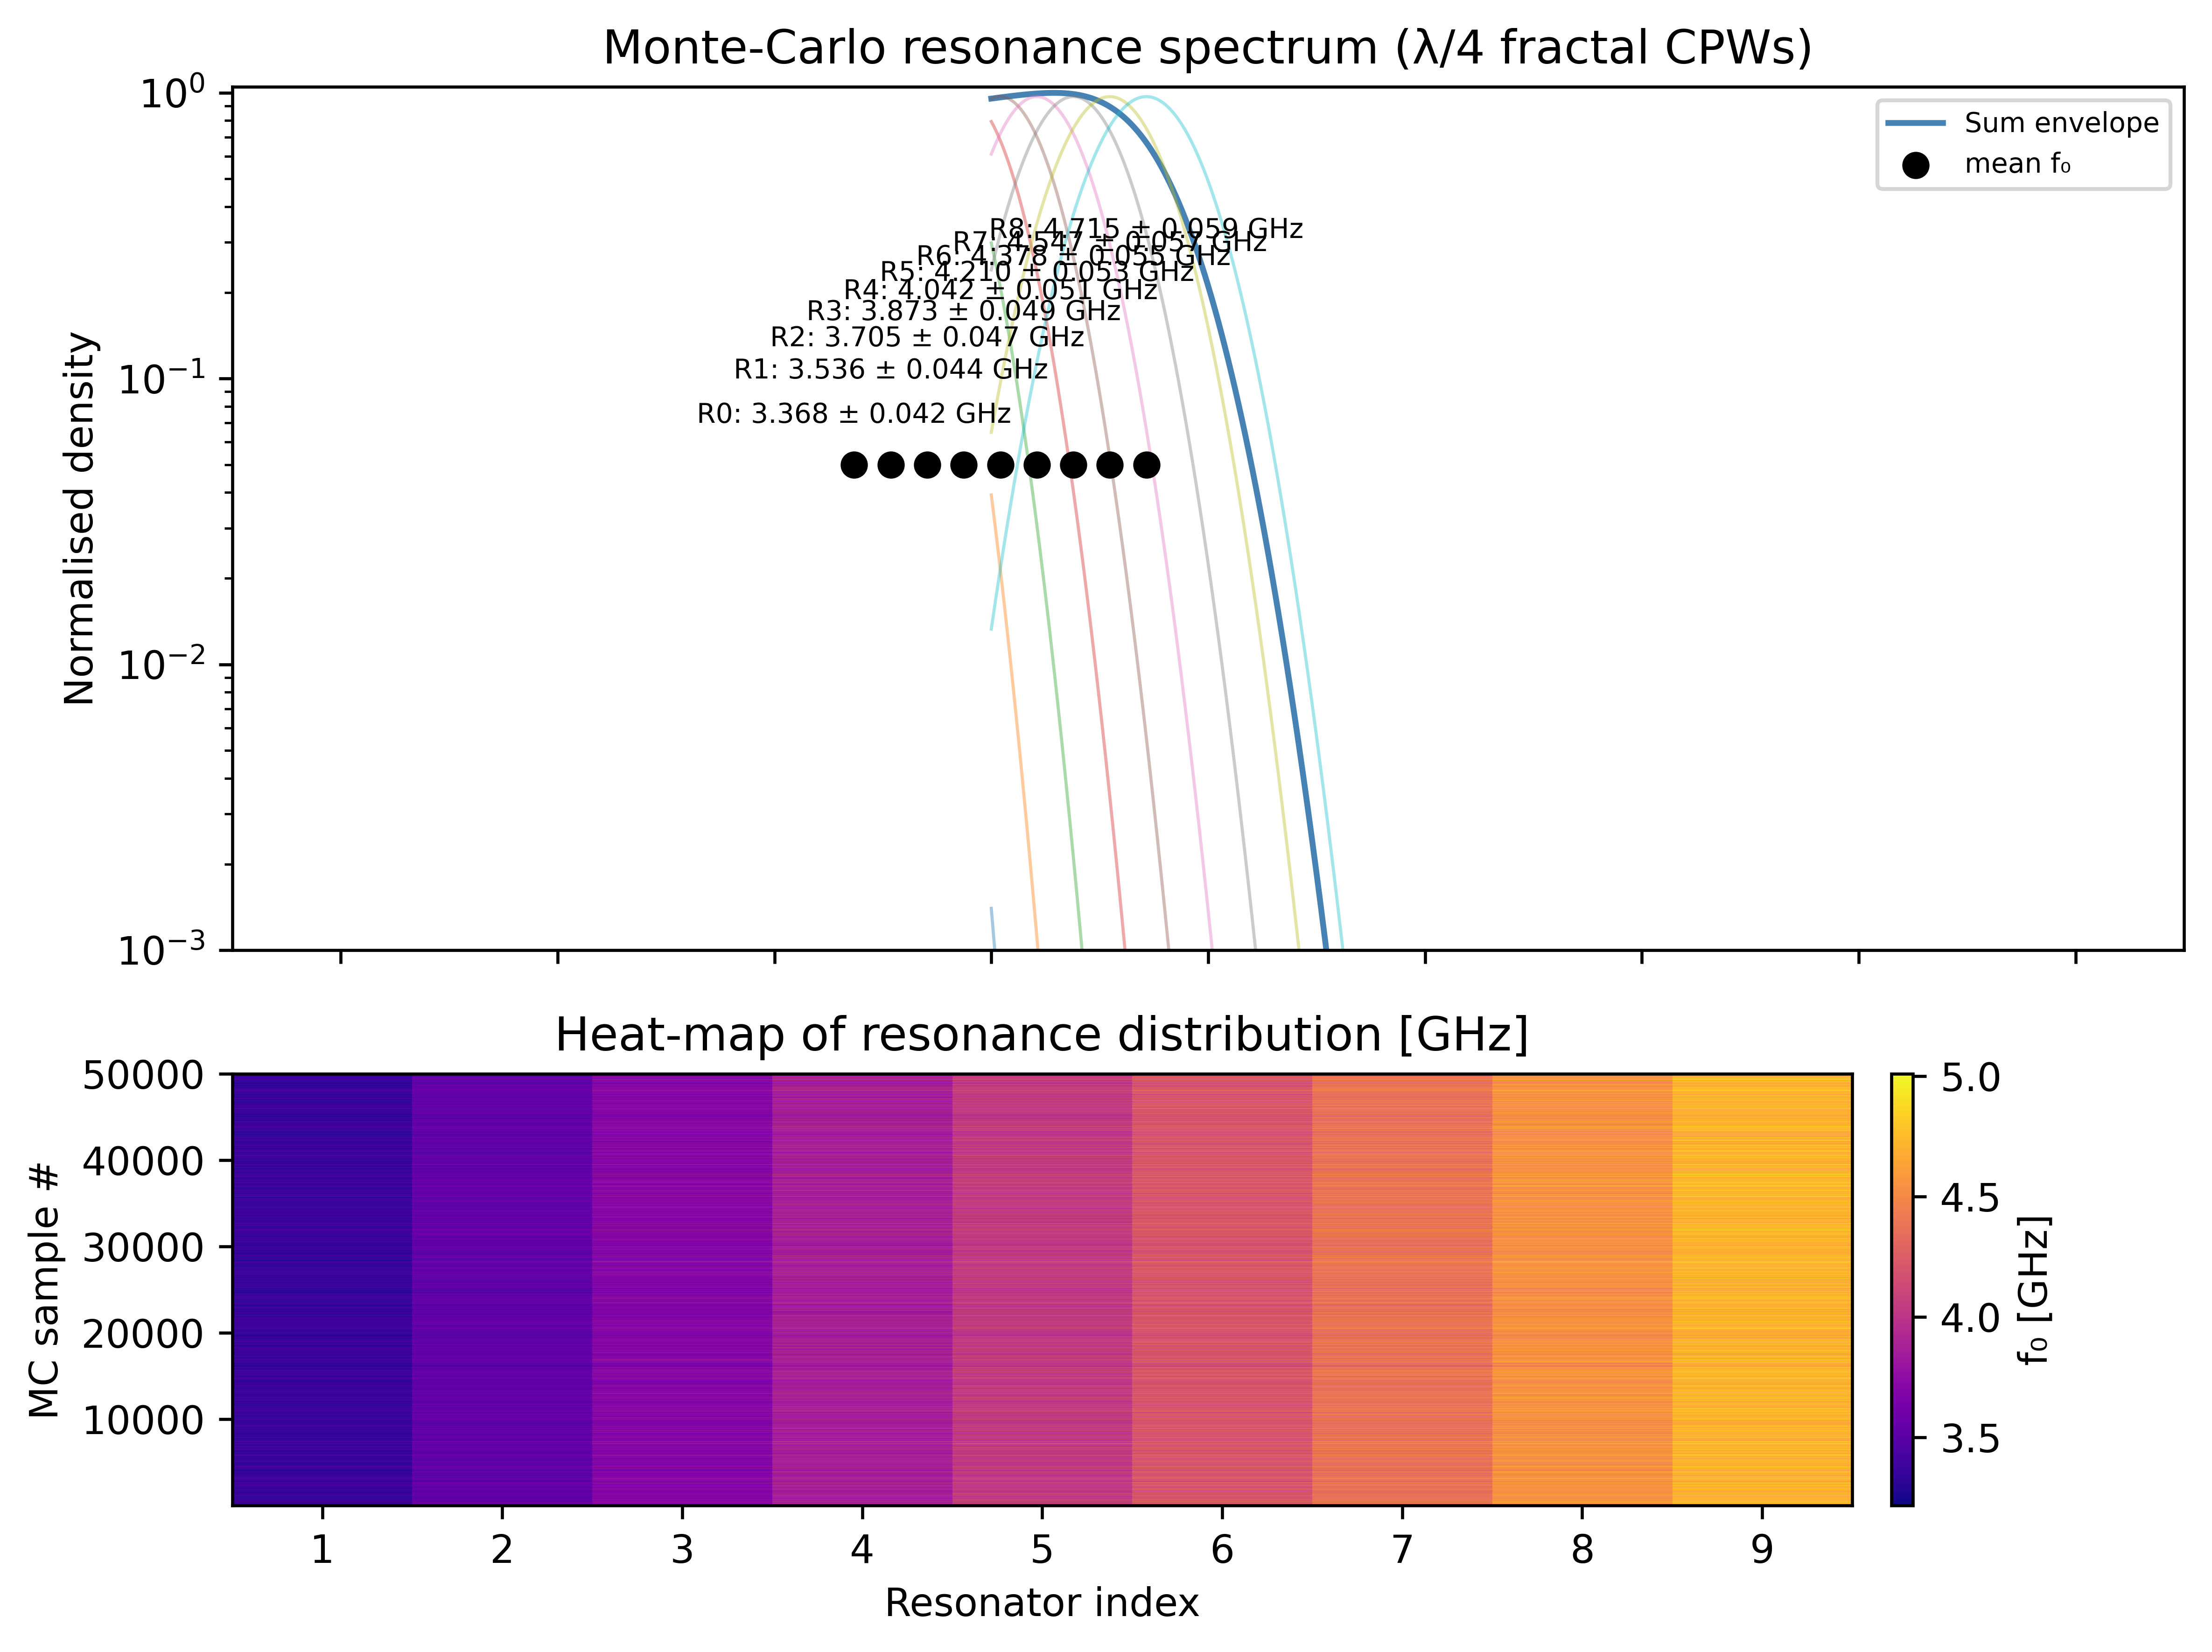

In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  GPU Monte-Carlo λ/4 Fractal-CPW Resonator Simulation    ║
# ║  (Option A: per-resonator KDE curves)                    ║
# ║  Requires: cupy-cuda12x, matplotlib, scipy               ║
# ║  Author:  Onri Jay Benally (2025-06-19)                  ║
# ╚══════════════════════════════════════════════════════════╝
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c

# ────────────────────────────────────────────────────────────
# 0) Geometry imported from your GDSTK layout cell
# ────────────────────────────────────────────────────────────
L_phys   = lambda_quarters * 1e-6            # μm → m
w_line   = tech["w_res"] * 1e-6
g_line   = tech.get("g_res", 6.0) * 1e-6
num_res  = NUM_RESONATORS
f_nom_Hz = freqs * 1e9

# ────────────────────────────────────────────────────────────
# 1)  Variations  (Option C values)
# ────────────────────────────────────────────────────────────
NSAMPLES          = 50_000
ε_r_sub           = 11.7
δ_w_local_rms     = 0.003      # 0.3 %
δ_L_local_rms     = 0.002      # 0.2 %
δ_ε_local_rms     = 0.010      # 1.0 %
USE_GLOBAL_SHIFT  = True
δ_w_global_rms    = 0.005      # 0.5 %
δ_L_global_rms    = 0.005      # 0.5 %
δ_ε_global_rms    = 0.020      # 2.0 %

# Visual options
USE_LOG_KDE       = True
BANDWIDTH_FACTOR  = 4.0
CMAP              = "plasma"

# ────────────────────────────────────────────────────────────
# 2) Promote constants to GPU
# ────────────────────────────────────────────────────────────
L0_cu  = cp.asarray(L_phys)[None, :]
w0_cu  = cp.asarray(w_line)
g_cu   = cp.asarray(g_line)
εr_cu  = cp.asarray(ε_r_sub)

# ────────────────────────────────────────────────────────────
# 3) Monte-Carlo perturbations
# ────────────────────────────────────────────────────────────
if USE_GLOBAL_SHIFT:
    δw_global = cp.random.normal(0, δ_w_global_rms, (NSAMPLES, 1))
    δL_global = cp.random.normal(0, δ_L_global_rms, (NSAMPLES, 1))
    δε_global = cp.random.normal(0, δ_ε_global_rms, (NSAMPLES, 1))
else:
    δw_global = δL_global = δε_global = 0.0

δw_local = cp.random.normal(0, δ_w_local_rms, (NSAMPLES, num_res))
δL_local = cp.random.normal(0, δ_L_local_rms, (NSAMPLES, num_res))
δε_local = cp.random.normal(0, δ_ε_local_rms, (NSAMPLES, num_res))

δ_w = δw_global + δw_local
δ_L = δL_global + δL_local
δ_ε = δε_global + δε_local

w_MC = w0_cu * (1 + δ_w)
L_MC = L0_cu * (1 + δ_L)
ε_MC = εr_cu * (1 + δ_ε)

# ────────────────────────────────────────────────────────────
# 4) ε_eff  (Hammerstad–Jensen)
# ────────────────────────────────────────────────────────────
def cpw_eps_eff(ε_r, w, g):
    k  = w / (w + 2*g)
    k1 = cp.sqrt(1 - k**2)
    K  = (np.pi/2)*(1 + k**2/4 + 9*k**4/64)
    K1 = (np.pi/2)*(1 + k1**2/4 + 9*k1**4/64)
    return (ε_r + 1)/2 + (ε_r - 1)/2 * (K1/K)

ε_eff_MC = cpw_eps_eff(ε_MC, w_MC, g_cu)
v_p_MC   = c / cp.sqrt(ε_eff_MC)
f0_MC    = v_p_MC / (4 * L_MC)               # (S,N)  Hz

# ────────────────────────────────────────────────────────────
# 5) Statistics & KDE
# ────────────────────────────────────────────────────────────
f0_mean = f0_MC.mean(axis=0).get() / 1e9      # GHz
f0_std  = f0_MC.std(axis=0).get()  / 1e9      # GHz

f_axis = np.linspace(f_nom_Hz.min()*0.8,
                     f_nom_Hz.max()*1.2, 2000)             # Hz
f_axis_cu   = cp.asarray(f_axis)[:,None,None]               # (F,1,1)
f0_expanded = f0_MC[None,:,:]                               # (1,S,N)
σ_cu        = cp.asarray(BANDWIDTH_FACTOR*f0_std*1e9)[None,None,:]

# Global envelope
kde = cp.exp(-((f_axis_cu - f0_expanded)**2)/(2*σ_cu**2)).sum(axis=(1,2))
kde_cpu = (kde / kde.max()).get()

# Per-resonator KDE (mean over samples)
kde_by_res = cp.exp(-((f_axis_cu - f0_expanded)**2)/(2*σ_cu**2)).mean(axis=1).get()
colors = plt.cm.tab10(np.linspace(0,1,num_res))

# ────────────────────────────────────────────────────────────
# 6) Plot
# ────────────────────────────────────────────────────────────
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(8,6),
                           gridspec_kw={'height_ratios':[2,1]},sharex=True)

# Global envelope
ax1.plot(f_axis/1e9,kde_cpu,lw=1.5,label="Sum envelope",color="steelblue")

# Per-resonator curves
for j in range(num_res):
    ax1.plot(f_axis/1e9, kde_by_res[:,j],
             lw=0.8, alpha=0.4, color=colors[j])

# Mean f₀ markers
ax1.scatter(f0_mean,[0.05]*num_res,c='k',zorder=3,label='mean f₀')
for i,(μ,σ) in enumerate(zip(f0_mean,f0_std)):
    ax1.annotate(f"R{i}: {μ:.3f} ± {σ:.3f} GHz",(μ,0.07+i*0.03),
                 fontsize=7,ha='center')

if USE_LOG_KDE:
    ax1.set_yscale('log'); ax1.set_ylim(1e-3,1.05)
ax1.set_ylabel("Normalised density")
ax1.set_title("Monte-Carlo resonance spectrum (λ/4 fractal CPWs)")
ax1.legend(fontsize=7)

# Heat-map
im=ax2.imshow(f0_MC.get()/1e9,aspect='auto',cmap=CMAP,
              extent=[0.5,num_res+0.5,1,NSAMPLES],
              origin='lower',interpolation='nearest')
ax2.set_xlabel("Resonator index")
ax2.set_ylabel("MC sample #")
ax2.set_title("Heat-map of resonance distribution [GHz]")
plt.colorbar(im,ax=ax2,pad=0.02,label="f₀ [GHz]")

plt.tight_layout(); plt.show()

/tmp/ipython-input-15-394782519.py:85: RuntimeWarning: invalid value encountered in divide
  S21_norm = S21_mean / S21_mean.max()



Predicted resonance frequencies (1–8 GHz sweep)
 idx |  mean ± 1σ  [GHz]
--------------------------------
 R0:  3.368 ±  0.042
 R1:  3.537 ±  0.044
 R2:  3.705 ±  0.046
 R3:  3.874 ±  0.049
 R4:  4.042 ±  0.051
 R5:  4.210 ±  0.053
 R6:  4.379 ±  0.055
 R7:  4.547 ±  0.057
 R8:  4.716 ±  0.059


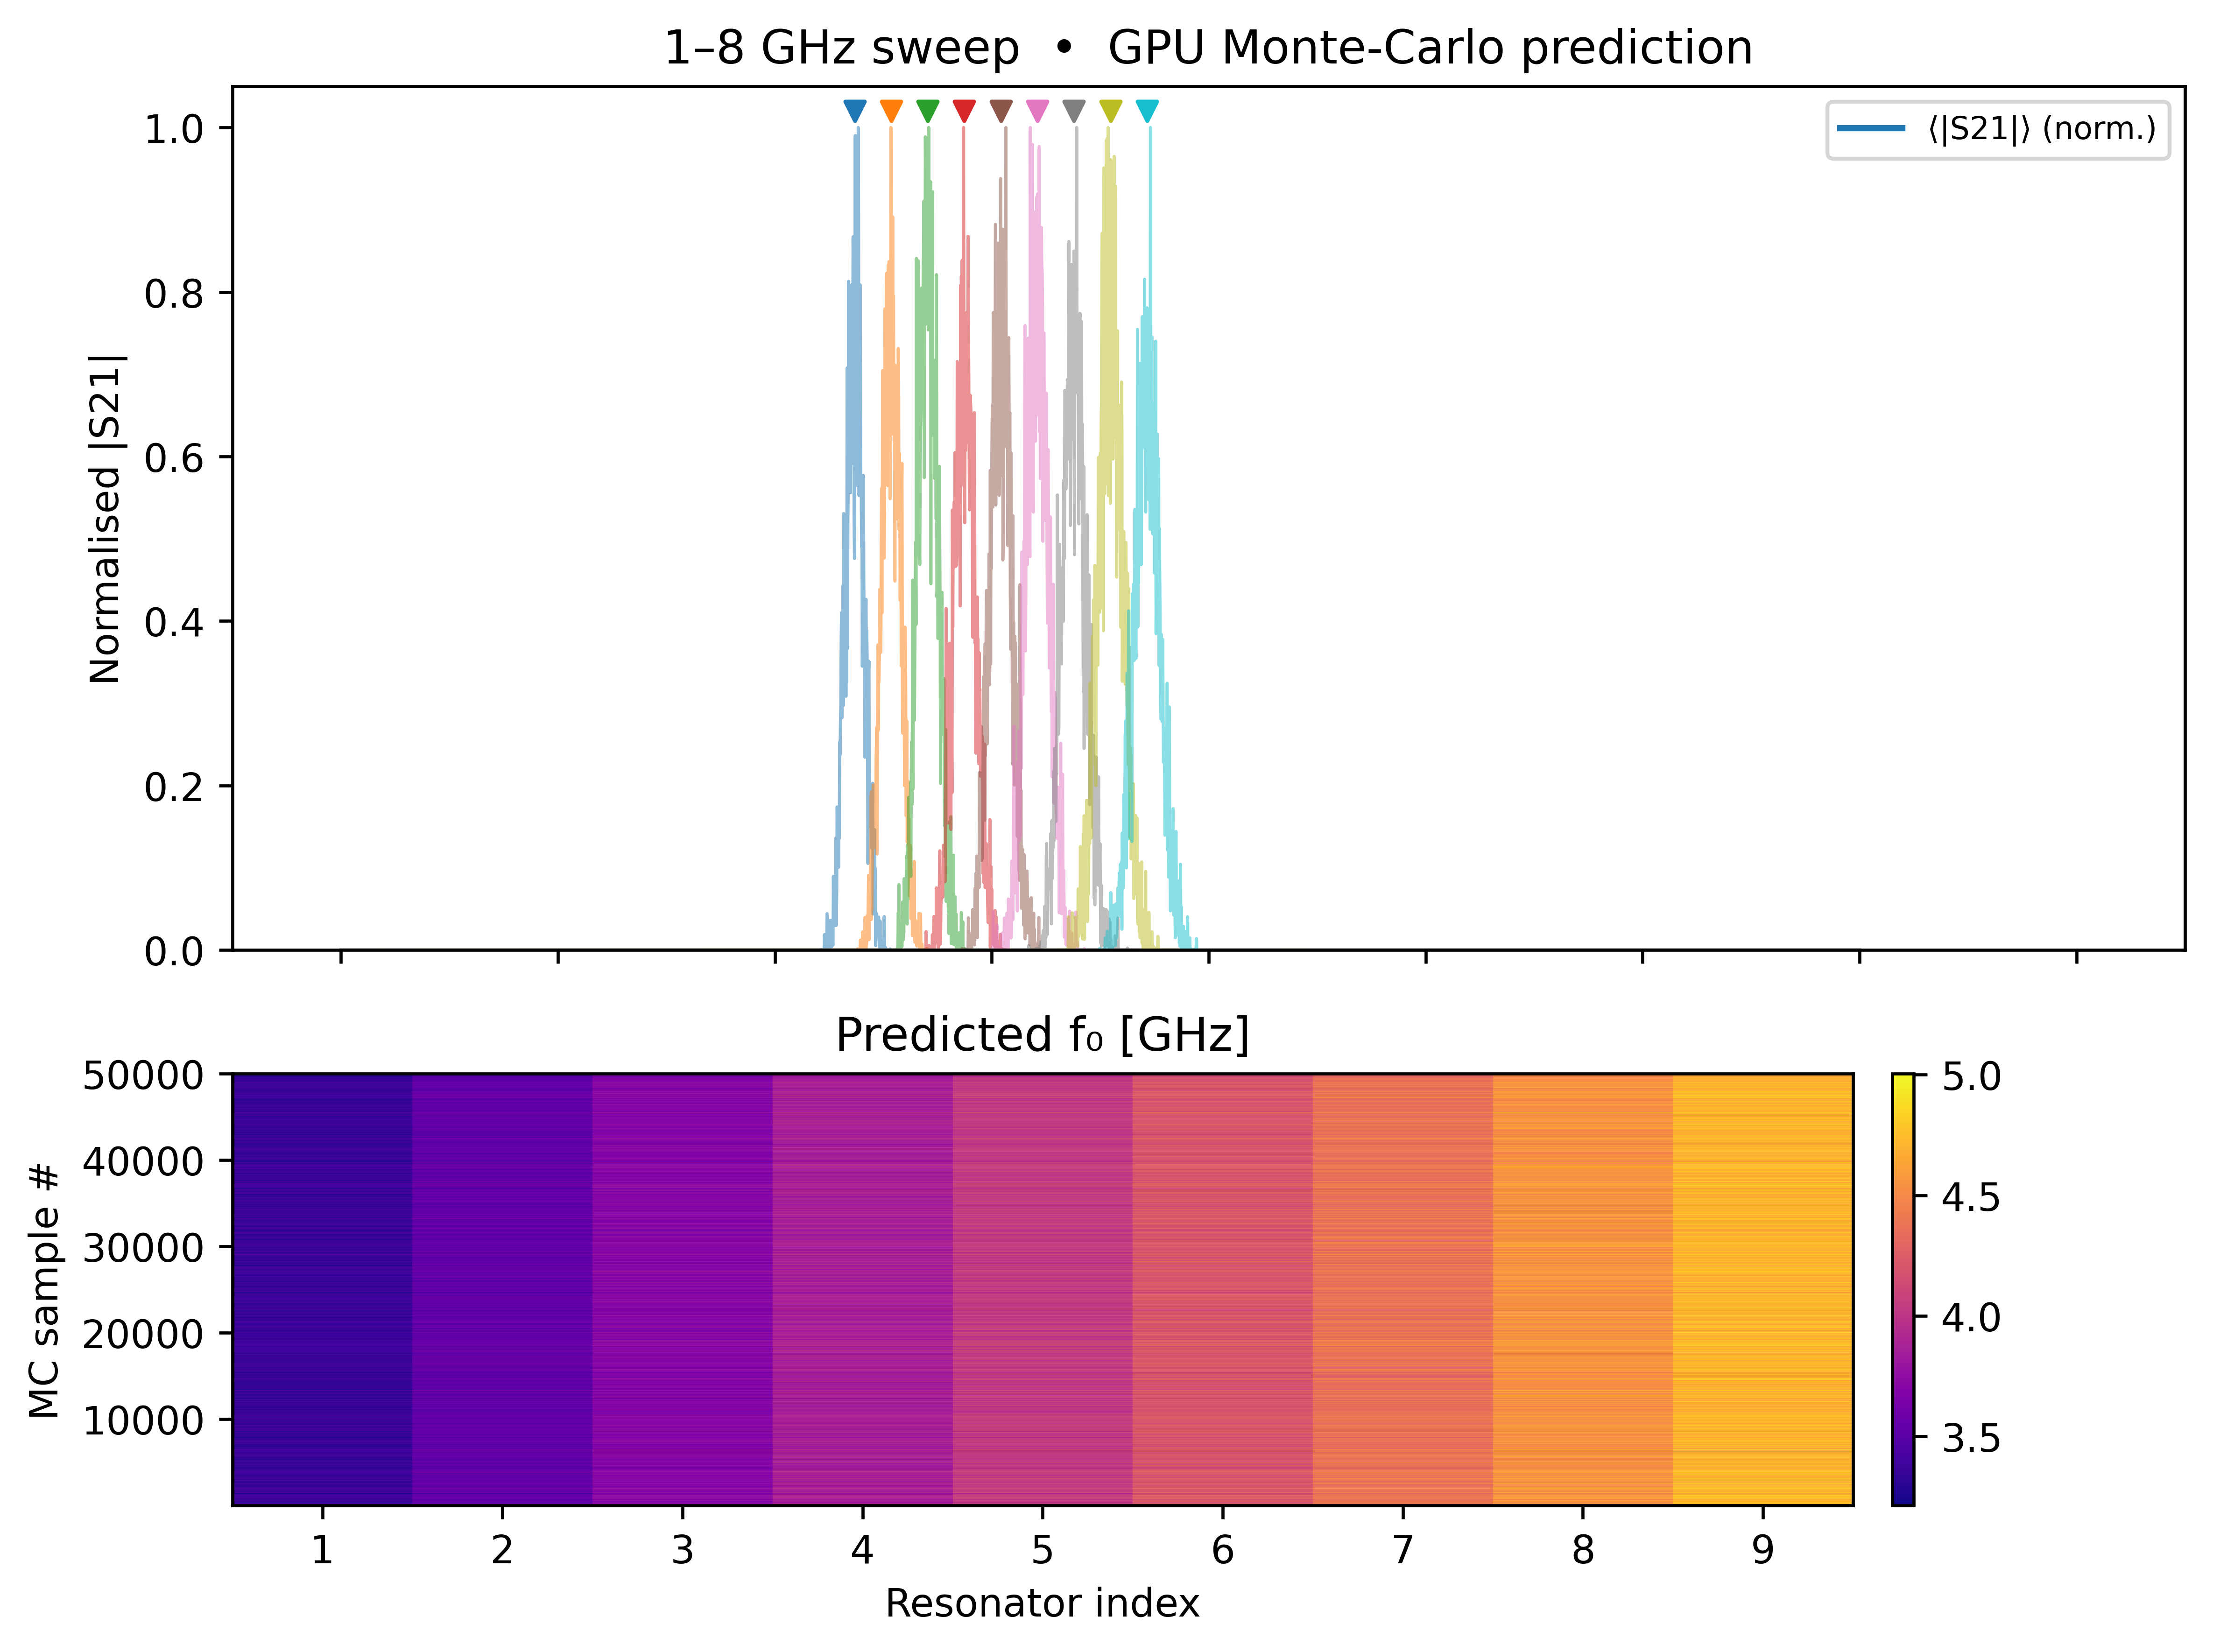

In [15]:
# ╔══════════════════════════════════════════════════════════╗
# ║  GPU Monte-Carlo λ/4 CPW Sweep  (1–8 GHz, normalised)    ║
# ║  • fp32 tensors | chunked accumulation                   ║
# ║  • Option B: normalise each |S21| curve to its max       ║
# ║  Author: Onri Jay Benally • 2025-06-19                   ║
# ╚══════════════════════════════════════════════════════════╝
import cupy as cp, numpy as np, matplotlib.pyplot as plt
from scipy.constants import c

DTYPE = cp.float32          # use fp32 to cut memory in half

# ── 0) geometry from GDSTK layout ───────────────────────────
L_phys = (lambda_quarters*1e-6).astype(np.float32)       # μm → m
w_line = np.float32(tech["w_res"]*1e-6)
g_line = np.float32(tech.get("g_res", 6.0)*1e-6)
num_res = NUM_RESONATORS

# ── 1) variation & sweep knobs  (Option C) ─────────────────
NSAMPLES = 50_000
ε_r_sub  = 11.7
δ_w_local_rms, δ_L_local_rms, δ_ε_local_rms = 0.003, 0.002, 0.010
USE_GLOBAL_SHIFT = True
δ_w_global_rms, δ_L_global_rms, δ_ε_global_rms = 0.005, 0.005, 0.020
F_SWEEP_MIN_GHZ, F_SWEEP_MAX_GHZ, N_FREQ_PTS = 1.0, 8.0, 4096
Q_int_fixed, Q_c_fixed = 3_000_000, 150_000
Q_L = 1.0 / (1/Q_int_fixed + 1/Q_c_fixed)

# ── 2) constants → GPU (fp32) ──────────────────────────────
L0_cu = cp.asarray(L_phys, dtype=DTYPE)[None, :]
w0_cu = cp.asarray(w_line, dtype=DTYPE)
g_cu  = cp.asarray(g_line, dtype=DTYPE)
εr_cu = cp.asarray(ε_r_sub, dtype=DTYPE)

# ── 3) Monte-Carlo perturbations ───────────────────────────
if USE_GLOBAL_SHIFT:
    δw_g = cp.random.normal(0, δ_w_global_rms, (NSAMPLES,1)).astype(DTYPE)
    δL_g = cp.random.normal(0, δ_L_global_rms, (NSAMPLES,1)).astype(DTYPE)
    δε_g = cp.random.normal(0, δ_ε_global_rms, (NSAMPLES,1)).astype(DTYPE)
else:
    δw_g = δL_g = δε_g = 0.0

δw_l = cp.random.normal(0, δ_w_local_rms, (NSAMPLES, num_res)).astype(DTYPE)
δL_l = cp.random.normal(0, δ_L_local_rms, (NSAMPLES, num_res)).astype(DTYPE)
δε_l = cp.random.normal(0, δ_ε_local_rms, (NSAMPLES, num_res)).astype(DTYPE)

w_MC = w0_cu * (1 + δw_g + δw_l)
L_MC = L0_cu * (1 + δL_g + δL_l)
ε_MC = εr_cu * (1 + δε_g + δε_l)

def ε_eff(ε_r, w, g):
    k  = w / (w + 2*g)
    k1 = cp.sqrt(1 - k**2)
    K  = (np.pi/2) * (1 + k**2/4 + 9*k**4/64)
    K1 = (np.pi/2) * (1 + k1**2/4 + 9*k1**4/64)
    return (ε_r + 1)/2 + (ε_r - 1)/2 * (K1/K)

ε_eff_MC = ε_eff(ε_MC, w_MC, g_cu)
v_p_MC   = DTYPE(c) / cp.sqrt(ε_eff_MC)
f0_MC    = v_p_MC / (4 * L_MC)                         # (S,N) Hz

# ── 4) sweep axis + streaming accumulators ────────────────
f_axis_Hz = cp.linspace(F_SWEEP_MIN_GHZ, F_SWEEP_MAX_GHZ,
                        N_FREQ_PTS, dtype=DTYPE) * 1e9           # (F,)
f_axis3   = f_axis_Hz[:, None, None]                             # (F,1,1)

S21_sum = cp.zeros((N_FREQ_PTS,), dtype=DTYPE)
lor_sum = cp.zeros((N_FREQ_PTS, num_res), dtype=DTYPE)

CHUNK = 5_000
for k in range((NSAMPLES + CHUNK - 1) // CHUNK):
    sl = slice(k*CHUNK, min((k+1)*CHUNK, NSAMPLES))
    f0_exp = f0_MC[sl][None, :, :]             # (1,chunk,N)

    num = 4 * Q_L**2 * ((f_axis3 - f0_exp)/f0_exp)**2
    lor = 1 / (1 + num)                        # (F,chunk,N)

    S21_sum += cp.prod(lor, axis=2).sum(axis=1)
    lor_sum += lor.sum(axis=1)

# averages to CPU
S21_mean = (S21_sum / NSAMPLES).get()
lor_mean_by_res = (lor_sum / NSAMPLES).get()

# ── normalise envelope & sub-curves (Option B) ─────────────
S21_norm = S21_mean / S21_mean.max()
lor_norm_by_res = lor_mean_by_res / lor_mean_by_res.max(axis=0, keepdims=True)

# stats for scatter markers
pred_f0 = f0_MC.get() / 1e9
mean_pred, std_pred = pred_f0.mean(0), pred_f0.std(0)

print("\nPredicted resonance frequencies (1–8 GHz sweep)")
print(" idx |  mean ± 1σ  [GHz]")
print("--------------------------------")
for i, (m, s) in enumerate(zip(mean_pred, std_pred)):
    print(f" R{i}: {m:6.3f} ± {s:6.3f}")

# ── 5) plots (normalised linear scale) ─────────────────────
f_axis_GHz = f_axis_Hz.get() / 1e9
cols = plt.cm.tab10(np.linspace(0, 1, num_res))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6),
                               gridspec_kw={'height_ratios':[2, 1]},
                               sharex=True)

ax1.plot(f_axis_GHz, S21_norm, lw=1.6, label="⟨|S21|⟩ (norm.)")

for n in range(num_res):
    ax1.plot(f_axis_GHz, lor_norm_by_res[:, n],
             lw=0.8, alpha=0.5, color=cols[n])
    ax1.scatter(mean_pred[n], 1.02, marker='v', s=25, color=cols[n])

ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Normalised |S21|")
ax1.set_title("1–8 GHz sweep  •  GPU Monte-Carlo prediction")
ax1.legend(fontsize=8, loc="upper right")

im = ax2.imshow(pred_f0, aspect='auto', cmap='plasma',
                extent=[0.5, num_res+0.5, 1, NSAMPLES],
                origin='lower', interpolation='nearest')
ax2.set_xlabel("Resonator index")
ax2.set_ylabel("MC sample #")
ax2.set_title("Predicted f₀ [GHz]")
plt.colorbar(im, ax=ax2, pad=0.02)

plt.tight_layout(); plt.show()